<a href="https://colab.research.google.com/github/Kumarkashish511/UCS761_Deep_Learning/blob/main/Climate_dataset_Sequence_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import math, time, os, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

print('All libraries loaded successfully!')


All libraries loaded successfully!


In [3]:
# Roll No: 102317239
# sum of digits = 1+0+2+3+1+7+2+3+9 = 28
# 28 % 10 + 8 = 18  (corrected: 28%10=8, 8+8=16)
WINDOW_SIZE = 16

# last 2 digits = 39
# PREDICTION_HORIZON = 39 % 3 + 1 = 0 + 1 = 1
PREDICTION_HORIZON = 1

# first 3 digits = 102
# HIDDEN_SIZE = 102 % 16 + 8 = 6 + 8 = 14
HIDDEN_SIZE = 14

# last digit is 9 (ODD), so we implement Prebuilt LSTM
print(f"Window Size: {WINDOW_SIZE}")
print(f"Prediction Horizon: {PREDICTION_HORIZON}")
print(f"Hidden Size: {HIDDEN_SIZE}")
print("Model: Prebuilt LSTM")


Window Size: 16
Prediction Horizon: 1
Hidden Size: 14
Model: Prebuilt LSTM


In [5]:
import os

# ── File path: update this to wherever your CSV is located ───────────────────
# Option 1: Running on Kaggle
KAGGLE_PATH = '/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv'
# Option 2: Running locally — place CSV in the SAME folder as this notebook
LOCAL_TRAIN = 'DailyDelhiClimateTrain.csv'
LOCAL_TEST  = 'DailyDelhiClimateTest.csv'

if os.path.exists(KAGGLE_PATH):
    file_path = KAGGLE_PATH
elif os.path.exists(LOCAL_TRAIN):
    file_path = LOCAL_TRAIN
elif os.path.exists(LOCAL_TEST):
    file_path = LOCAL_TEST
    print('Note: Using Test CSV. For best results use DailyDelhiClimateTrain.csv')
else:
    raise FileNotFoundError(
        'CSV not found! Place DailyDelhiClimateTrain.csv (or DailyDelhiClimateTest.csv) '
        'in the same folder as this notebook and re-run.'
    )

print(f'Loading: {file_path}')
df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')

# we forecast mean temperature – a continuous, well-behaved univariate signal
TARGET_COL = 'meantemp'
df = df[[TARGET_COL]].dropna()

scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(df.values)

print(f'scaled_data shape: {scaled_data.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')


Note: Using Test CSV. For best results use DailyDelhiClimateTrain.csv
Loading: DailyDelhiClimateTest.csv
scaled_data shape: (114, 1)
Date range: 2017-01-01 to 2017-04-24


In [6]:
def create_sequences(data, window_size, horizon):
    """
    converts raw time series into input-output pairs.
    input: past 'window_size' steps
    output: future 'horizon' steps
    """
    xs, ys = [], []
    for i in range(len(data) - window_size - horizon + 1):
        x = data[i:(i + window_size)]
        y = data[(i + window_size):(i + window_size + horizon)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, WINDOW_SIZE, PREDICTION_HORIZON)

# chronological split (no random shuffling for time series)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# convert to pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: torch.Size([78, 16, 1]), y_train shape: torch.Size([78, 1, 1])
X_test shape: torch.Size([20, 16, 1]), y_test shape: torch.Size([20, 1, 1])


In [7]:
class MLPBaseline(nn.Module):
    def __init__(self, input_size, window_size, hidden_size, output_size):
        super(MLPBaseline, self).__init__()
        # mlp flattens the sequence, losing temporal order
        self.fc1 = nn.Linear(input_size * window_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # flatten (batch, seq, features) -> (batch, seq * features)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size

        # input to hidden weights
        self.W_ih = nn.Parameter(torch.Tensor(input_size, hidden_size))
        # hidden to hidden weights (recurrent)
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        # hidden bias
        self.b_h = nn.Parameter(torch.Tensor(hidden_size))

        # hidden to output weights
        self.W_ho = nn.Parameter(torch.Tensor(hidden_size, output_size))
        # output bias
        self.b_o = nn.Parameter(torch.Tensor(output_size))

        # initialize weights properly
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size = x.size(0)
        seq_len = x.size(1)

        # initialize hidden state to zeros
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # process sequence step by step
        for t in range(seq_len):
            x_t = x[:, t, :]
            # h_t = tanh(x_t * W_ih + h_{t-1} * W_hh + b_h)
            h_t = torch.tanh(torch.matmul(x_t, self.W_ih) + torch.matmul(h_t, self.W_hh) + self.b_h)

        # final prediction using the last hidden state
        output = torch.matmul(h_t, self.W_ho) + self.b_o
        return output

In [9]:
class PrebuiltLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PrebuiltLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # lstm returns output and (hidden, cell) states
        out, _ = self.lstm(x)
        # use the last output
        out = self.fc(out[:, -1, :])
        return out

class SimpleTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_heads=2):
        super(SimpleTransformer, self).__init__()
        # project input to hidden_size
        self.input_proj = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer(x)
        # pool over the sequence
        out = out.mean(dim=1)
        out = self.fc(out)
        return out

def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)

        # y_train shape might be (batch, horizon, 1), squeeze it
        loss = criterion(outputs, y_train.squeeze(-1))

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if (epoch+1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

    return losses

def evaluate_model(model, X_test, y_test, scaler, name="Model"):
    model.eval()
    with torch.no_grad():
        preds = model(X_test)

    # inverse transform to get actual values
    # note: preds might be (batch, horizon)
    preds_np = preds.numpy()
    y_test_np = y_test.squeeze(-1).numpy()

    # if horizon > 1, we just evaluate the first prediction step for simplicity
    # or evaluate all. here we evaluate all steps flattened
    preds_inv = scaler.inverse_transform(preds_np.reshape(-1, 1))
    y_test_inv = scaler.inverse_transform(y_test_np.reshape(-1, 1))

    mse = mean_squared_error(y_test_inv, preds_inv)
    mae = mean_absolute_error(y_test_inv, preds_inv)
    rmse = math.sqrt(mse)

    print(f"--- {name} Metrics ---")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return preds_np, y_test_np, preds_inv, y_test_inv

In [10]:
print("Training Prebuilt LSTM (Primary Model for odd last digit)...")
primary_model = PrebuiltLSTM(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
primary_losses = train_model(primary_model, X_train, y_train, epochs=200, lr=0.005)
primary_preds, primary_y, primary_preds_inv, primary_y_inv = evaluate_model(primary_model, X_test, y_test, scaler, "Prebuilt LSTM")


Training Prebuilt LSTM (Primary Model for odd last digit)...
Epoch [20/200], Loss: 0.033747
Epoch [40/200], Loss: 0.021583
Epoch [60/200], Loss: 0.008898
Epoch [80/200], Loss: 0.008275
Epoch [100/200], Loss: 0.007934
Epoch [120/200], Loss: 0.007673
Epoch [140/200], Loss: 0.007422
Epoch [160/200], Loss: 0.007170
Epoch [180/200], Loss: 0.006913
Epoch [200/200], Loss: 0.006642
--- Prebuilt LSTM Metrics ---
MSE: 3.0560
MAE: 1.2456
RMSE: 1.7481


In [11]:
print("MLP Baseline...")
mlp_model = MLPBaseline(input_size=1, window_size=WINDOW_SIZE, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
mlp_losses = train_model(mlp_model, X_train, y_train, epochs=200, lr=0.005)
mlp_preds, mlp_y, mlp_preds_inv, mlp_y_inv = evaluate_model(mlp_model, X_test, y_test, scaler, "MLP Baseline")


MLP Baseline...
Epoch [20/200], Loss: 0.041261
Epoch [40/200], Loss: 0.014598
Epoch [60/200], Loss: 0.010826
Epoch [80/200], Loss: 0.010055
Epoch [100/200], Loss: 0.009305
Epoch [120/200], Loss: 0.008651
Epoch [140/200], Loss: 0.008065
Epoch [160/200], Loss: 0.007550
Epoch [180/200], Loss: 0.007106
Epoch [200/200], Loss: 0.006732
--- MLP Baseline Metrics ---
MSE: 5.6812
MAE: 1.8402
RMSE: 2.3835


In [12]:
print("\nTraining Custom RNN (for comparison)...")
rnn_model = CustomRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
rnn_losses = train_model(rnn_model, X_train, y_train, epochs=200, lr=0.005)
rnn_preds, rnn_y, rnn_preds_inv, rnn_y_inv = evaluate_model(rnn_model, X_test, y_test, scaler, "Custom RNN")

print("\nTraining Transformer...")
tf_model = SimpleTransformer(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
tf_losses = train_model(tf_model, X_train, y_train, epochs=200, lr=0.005)
tf_preds, tf_y, tf_preds_inv, tf_y_inv = evaluate_model(tf_model, X_test, y_test, scaler, "Transformer")



Training Custom RNN (for comparison)...
Epoch [20/200], Loss: 0.031837
Epoch [40/200], Loss: 0.009856
Epoch [60/200], Loss: 0.007078
Epoch [80/200], Loss: 0.006584
Epoch [100/200], Loss: 0.006222
Epoch [120/200], Loss: 0.005929
Epoch [140/200], Loss: 0.005688
Epoch [160/200], Loss: 0.005487
Epoch [180/200], Loss: 0.005321
Epoch [200/200], Loss: 0.005187
--- Custom RNN Metrics ---
MSE: 2.1647
MAE: 1.0481
RMSE: 1.4713

Training Transformer...
Epoch [20/200], Loss: 0.053194
Epoch [40/200], Loss: 0.012251
Epoch [60/200], Loss: 0.011069
Epoch [80/200], Loss: 0.010509
Epoch [100/200], Loss: 0.010032
Epoch [120/200], Loss: 0.010162
Epoch [140/200], Loss: 0.009115
Epoch [160/200], Loss: 0.009764
Epoch [180/200], Loss: 0.009902
Epoch [200/200], Loss: 0.009239
--- Transformer Metrics ---
MSE: 7.5513
MAE: 2.3559
RMSE: 2.7480


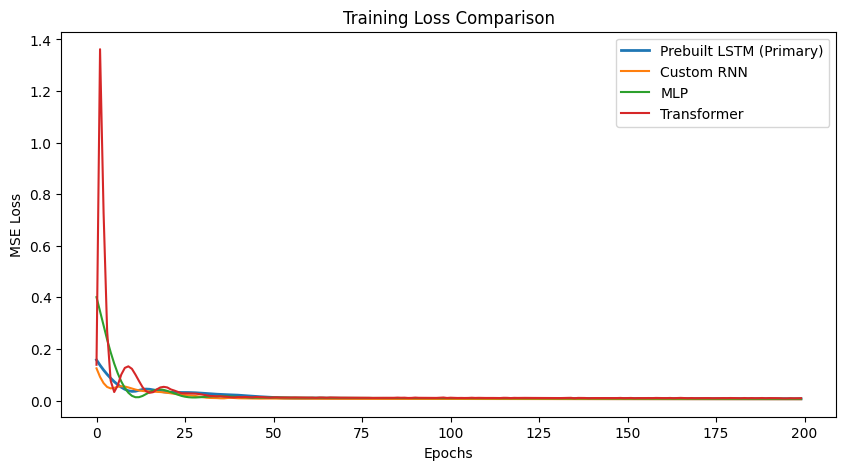

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(primary_losses, label='Prebuilt LSTM (Primary)', linewidth=2)
plt.plot(rnn_losses, label='Custom RNN')
plt.plot(mlp_losses, label='MLP')
plt.plot(tf_losses, label='Transformer')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


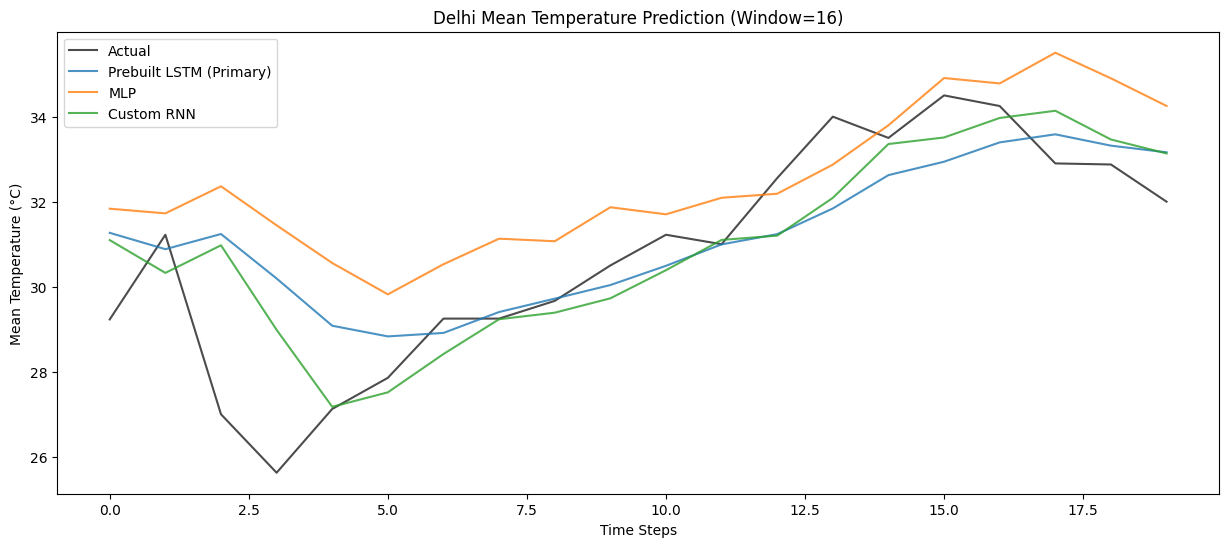

In [14]:
plt.figure(figsize=(15, 6))
plt.plot(primary_y_inv[0::PREDICTION_HORIZON], label='Actual', color='black', alpha=0.7)
plt.plot(primary_preds_inv[0::PREDICTION_HORIZON], label='Prebuilt LSTM (Primary)', alpha=0.8)
plt.plot(mlp_preds_inv[0::PREDICTION_HORIZON], label='MLP', alpha=0.8)
plt.plot(rnn_preds_inv[0::PREDICTION_HORIZON], label='Custom RNN', alpha=0.8)
plt.title(f'Delhi Mean Temperature Prediction (Window={WINDOW_SIZE})')
plt.xlabel('Time Steps')
plt.ylabel('Mean Temperature (°C)')
plt.legend()
plt.show()


In [15]:
print("\n Ablation Study: Window Sizes ")
ablation_windows = [WINDOW_SIZE // 2, WINDOW_SIZE, WINDOW_SIZE * 2]

for w in ablation_windows:
    if w <= 0: continue
    print(f"\nTesting Window Size: {w}")
    X_ab, y_ab = create_sequences(scaled_data, w, PREDICTION_HORIZON)
    train_sz = int(len(X_ab) * 0.8)
    X_ab_tr, X_ab_te = torch.tensor(X_ab[:train_sz], dtype=torch.float32), torch.tensor(X_ab[train_sz:], dtype=torch.float32)
    y_ab_tr, y_ab_te = torch.tensor(y_ab[:train_sz], dtype=torch.float32), torch.tensor(y_ab[train_sz:], dtype=torch.float32)

    ab_model = CustomRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
    train_model(ab_model, X_ab_tr, y_ab_tr, epochs=150, lr=0.005)
    evaluate_model(ab_model, X_ab_te, y_ab_te, scaler, f"Custom RNN (Window={w})")


 Ablation Study: Window Sizes 

Testing Window Size: 8
Epoch [20/150], Loss: 0.036598
Epoch [40/150], Loss: 0.025476
Epoch [60/150], Loss: 0.014039
Epoch [80/150], Loss: 0.007594
Epoch [100/150], Loss: 0.007162
Epoch [120/150], Loss: 0.006871
Epoch [140/150], Loss: 0.006623
--- Custom RNN (Window=8) Metrics ---
MSE: 2.6803
MAE: 1.3615
RMSE: 1.6372

Testing Window Size: 16
Epoch [20/150], Loss: 0.032492
Epoch [40/150], Loss: 0.012487
Epoch [60/150], Loss: 0.008276
Epoch [80/150], Loss: 0.007196
Epoch [100/150], Loss: 0.006761
Epoch [120/150], Loss: 0.006452
Epoch [140/150], Loss: 0.006196
--- Custom RNN (Window=16) Metrics ---
MSE: 2.6118
MAE: 1.3329
RMSE: 1.6161

Testing Window Size: 32
Epoch [20/150], Loss: 0.035834
Epoch [40/150], Loss: 0.023244
Epoch [60/150], Loss: 0.012414
Epoch [80/150], Loss: 0.007010
Epoch [100/150], Loss: 0.006687
Epoch [120/150], Loss: 0.006372
Epoch [140/150], Loss: 0.006147
--- Custom RNN (Window=32) Metrics ---
MSE: 3.0684
MAE: 1.5357
RMSE: 1.7517


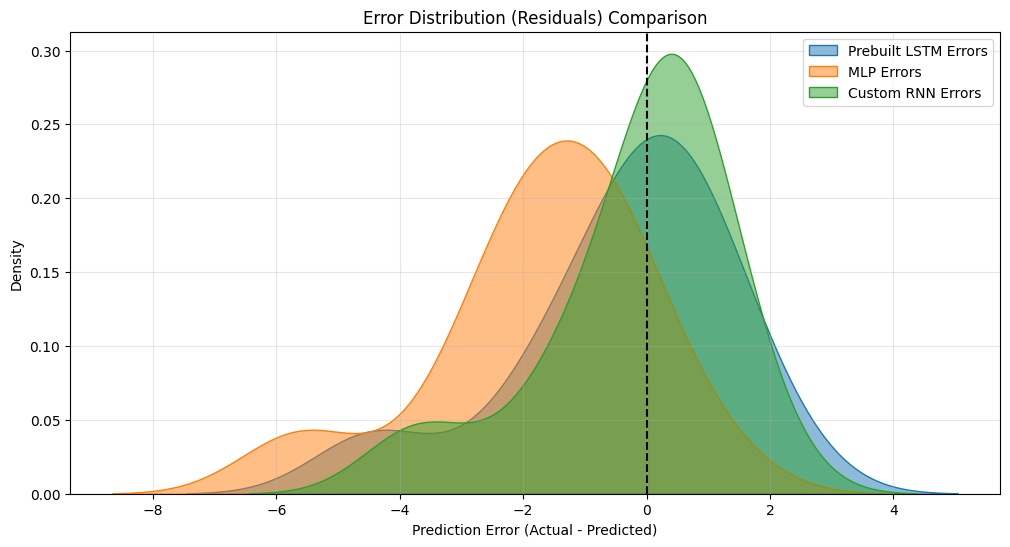

In [16]:
import seaborn as sns

# calculate errors
primary_err = primary_y_inv[0::PREDICTION_HORIZON] - primary_preds_inv[0::PREDICTION_HORIZON]
mlp_err = mlp_y_inv[0::PREDICTION_HORIZON] - mlp_preds_inv[0::PREDICTION_HORIZON]
rnn_err = rnn_y_inv[0::PREDICTION_HORIZON] - rnn_preds_inv[0::PREDICTION_HORIZON]

plt.figure(figsize=(12, 6))
sns.kdeplot(primary_err.flatten(), fill=True, label='Prebuilt LSTM Errors', alpha=0.5)
sns.kdeplot(mlp_err.flatten(), fill=True, label='MLP Errors', alpha=0.5)
sns.kdeplot(rnn_err.flatten(), fill=True, label='Custom RNN Errors', alpha=0.5)

plt.title('Error Distribution (Residuals) Comparison')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Density')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


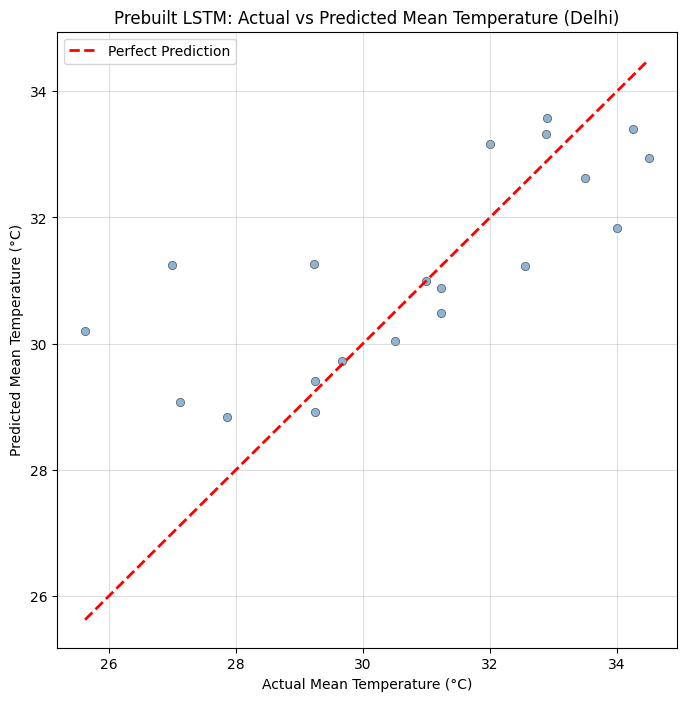

In [17]:
plt.figure(figsize=(8, 8))

# plot the Prebuilt LSTM predictions (primary model)
plt.scatter(primary_y_inv[0::PREDICTION_HORIZON], primary_preds_inv[0::PREDICTION_HORIZON],
            alpha=0.6, color='steelblue', edgecolor='black', linewidth=0.5)

# plot the perfect prediction diagonal line
min_val = min(primary_y_inv.min(), primary_preds_inv.min())
max_val = max(primary_y_inv.max(), primary_preds_inv.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.title('Prebuilt LSTM: Actual vs Predicted Mean Temperature (Delhi)')
plt.xlabel('Actual Mean Temperature (°C)')
plt.ylabel('Predicted Mean Temperature (°C)')
plt.legend()
plt.grid(alpha=0.4)
plt.show()
